# **Milestone 1: exploration phase**
### **1- Load dataset & apply the data processing used in the last module**

In [1]:
import pandas as pd
import os

os.chdir('/home/miguel/zrive-ds')

from src.module_3.metrics_fun import *

os.chdir('/home/miguel/zrive-ds')

dataset_path = "data/groceries/sampled_box_builder_df.csv"
df = pd.read_csv(dataset_path)
df = df[df.groupby('order_id')['outcome'].transform('sum') >= 5]

# Data processing (frecuencial categorical encoding and handling time variables) + 3 way split (the function for data processing is called inside the time_based split)
X_train, X_val, X_test, y_train, y_val, y_test = time_based_split(df, date_column='order_date', train_size=0.7, val_size=0.15, test_size=0.15)

### **Define our metrics & baseline**

- **Metrics:**
As it was done throughout the previous module, the metrics that will be used are the plots of both the ROC curve and Precision-Recall curve. This election is made becaude we do not know which are the company's requirements for precision or recall rates, so the curves are a visual way to compare performances.

- **Baseline:**
The baseline for this exploration will be the linear model chosen after the exploration done in the previous module. This is because it won't make sense to build and implement a more complex model unless it shows arguably better results than a simple one. That linear model is imported as follows:

In [2]:
import joblib

baseline_path = "models/module_3/20250214-153219_Linear Model.pkl"
baseline = joblib.load(baseline_path)

### **Try non-linear models**

In first place, we are going to implement a simple decision tree, and we are going to evaluate its results depending on its `max_depth` (the number of 'levels' that the tree can have).

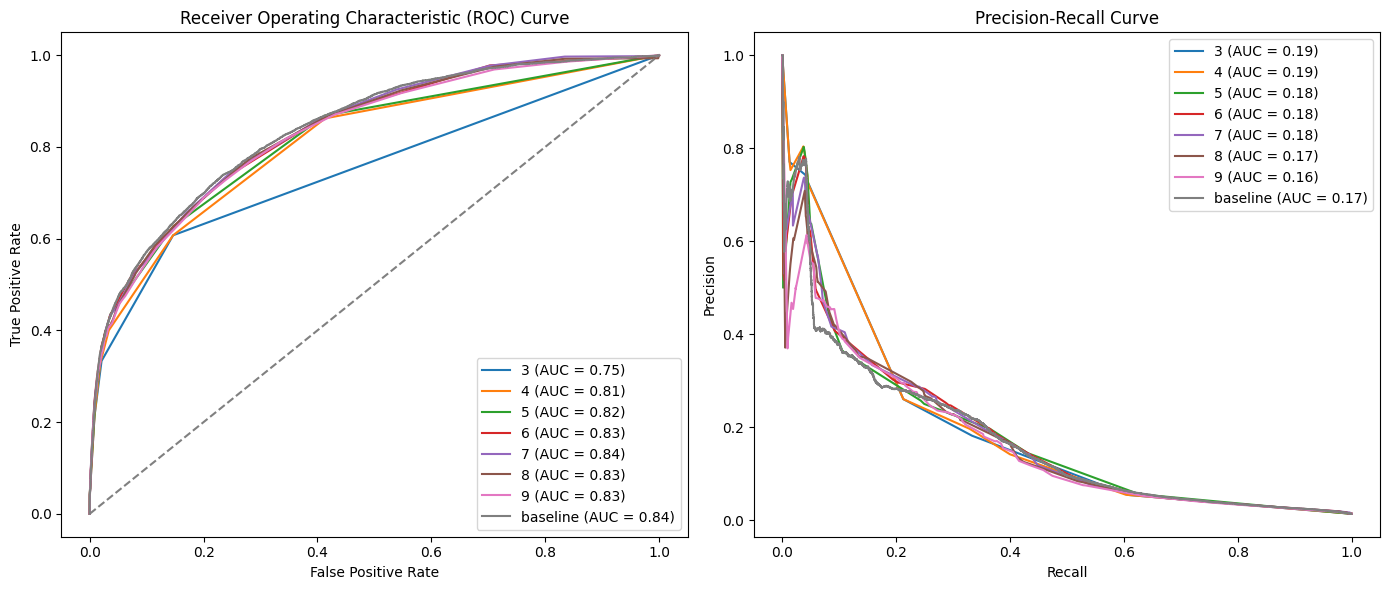

In [3]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

initial_depth = 3
final_depth = 10
decision_trees = []

for depth in range(initial_depth, final_depth):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    decision_trees.append(tree)

decision_trees.append(baseline)

plot_roc_pr_curves(decision_trees, X_val, y_val, model_names=np.append(np.arange(initial_depth, final_depth), 'baseline'))

Even though we can see some slight improves in performance (specially when we seek high values in precision) the curves obtained for simple decision trees do not provide a clear argument to be chosen over our baseline. Let's move on to the implementation of a Random Forest.

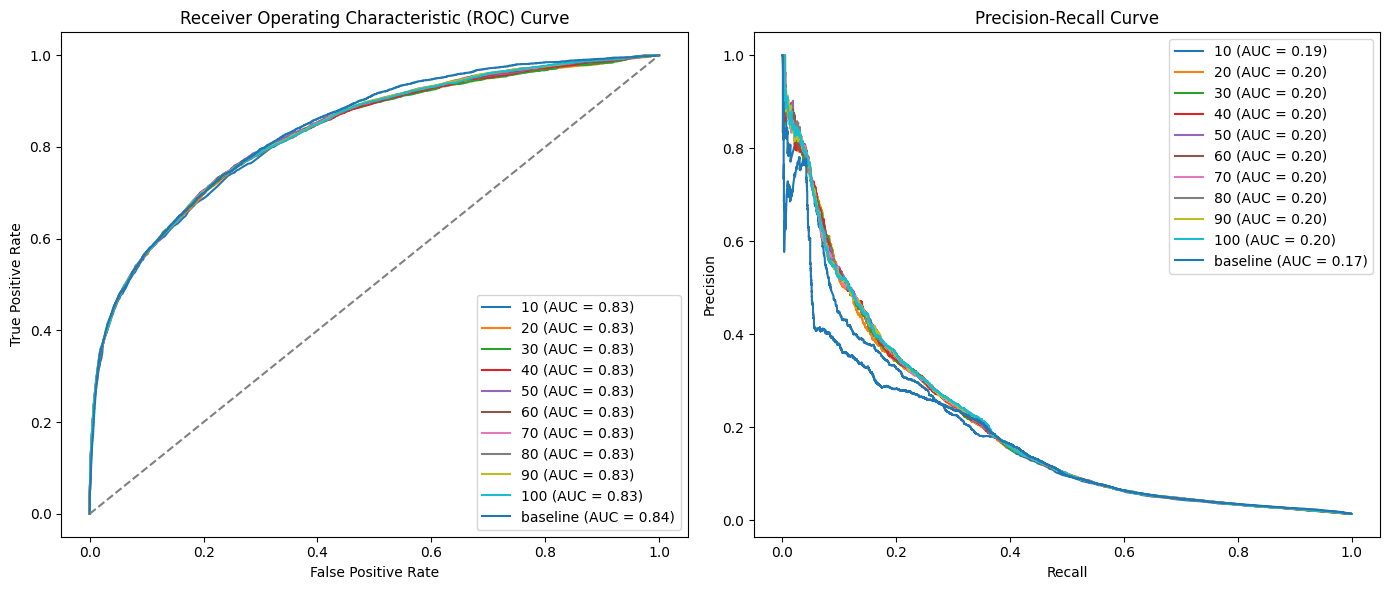

In [4]:
from sklearn.ensemble import RandomForestClassifier

initial_trees = 10
final_trees = 100
step = 10 
random_forests = []

for n_trees in range(initial_trees, final_trees + 1, step):
    rf = RandomForestClassifier(n_estimators=n_trees, max_depth=5, random_state=42)
    rf.fit(X_train, y_train)
    random_forests.append(rf)

random_forests.append(baseline)

plot_roc_pr_curves(random_forests, X_val, y_val, model_names=np.append(np.arange(initial_trees, final_trees + 1, step), 'baseline'))

Looking at these curves, we see a larger improvement over the baseline defined. It can be clearly seen for precision values over 0.2, where the RandomForest models improve significantly their PR curves (producing more stable results as well). We can also appreciate that performance of Random Forests improves until 30/40 trees (`n_estimators`), where it becomes quite constant (as we saw in class, RF models stop improving at some point when we increes the tree number, but do not become worse, just computationally heavier).

After this, we will try some more sofisticated procedures in order to adjust both hyperparameters: `n_estimators` & `max_depth`. Let's try a Randomized Search.

Fitting 2 folds for each of 5 candidates, totalling 10 fits
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.8min
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.8min
[CV] END max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=5, n_estimators=150; total time= 2.7min
[CV] END max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=5, n_estimators=150; total time= 2.7min
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.2min
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.2min
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=150; total time= 2.7min
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=150;

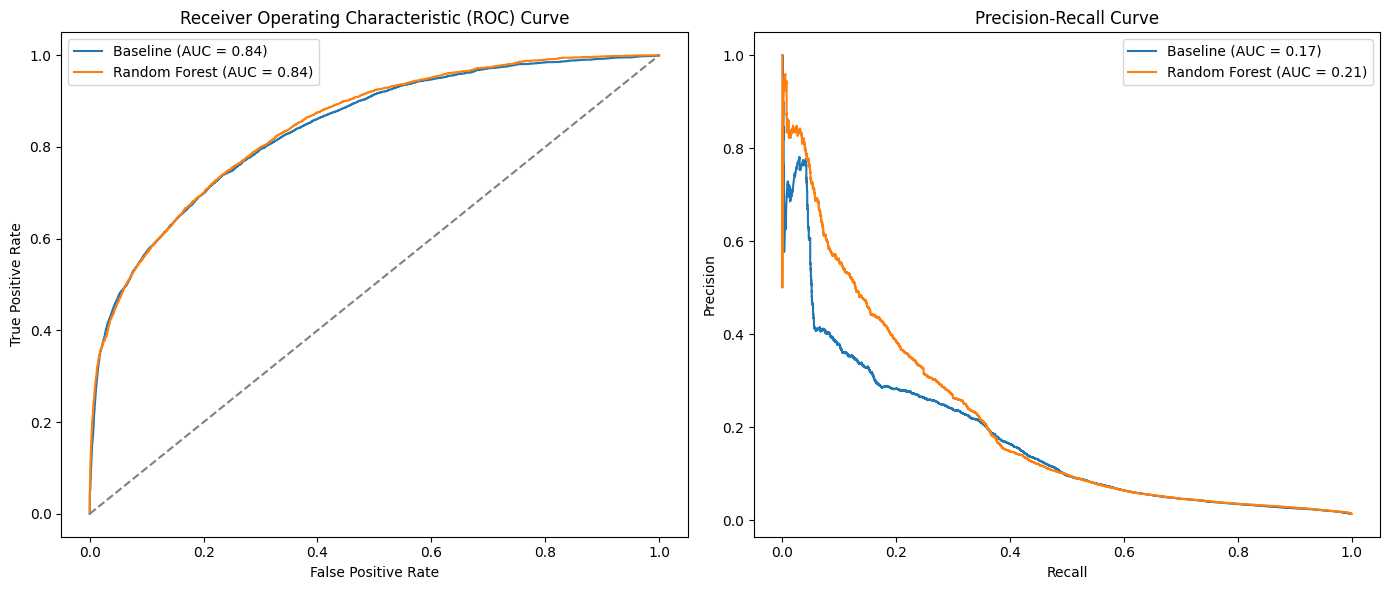

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': np.arange(50, 200, 50),
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

# Perform Randomized Search
# random_search = RandomizedSearchCV(rf, param_distributions=param_grid, n_iter=20, cv=3, scoring='roc_auc', n_jobs=4, random_state=42, verbose=2)
random_search = RandomizedSearchCV(rf, param_distributions=param_grid, n_iter=5, cv=2, scoring='roc_auc', n_jobs=4, random_state=42, verbose=2)
random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_

print(f"Best parameters: {random_search.best_params_}")

plot_roc_pr_curves([baseline, best_rf], X_val, y_val, model_names=['Baseline', 'Random Forest'])


Best parameters obtained: `n_estimators`: 100, `min_samples_split`: 2, `min_samples_leaf`: 1, `max_features`: 'sqrt', `max_depth`: 10.

Now, let's check feature importance and see if we can simplify the model chosen.

Selected 16 features out of 23


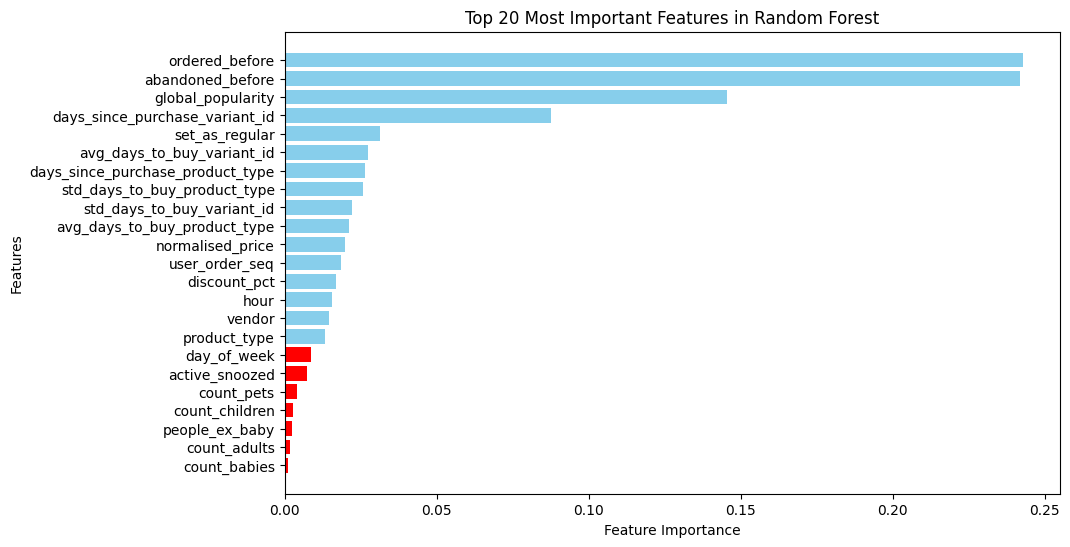

In [6]:
importances = best_rf.feature_importances_

feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

top_features = feature_importance_df[feature_importance_df['Importance'] > 0.01]['Feature'].values

X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

print(f"Selected {len(top_features)} features out of {X_train.shape[1]}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(feature_importance_df['Feature'][:len(top_features)], feature_importance_df['Importance'][:len(top_features)], color='skyblue')
plt.barh(feature_importance_df['Feature'][len(top_features):], feature_importance_df['Importance'][len(top_features):], color='red')

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 20 Most Important Features in Random Forest")
plt.gca().invert_yaxis()  
plt.show()

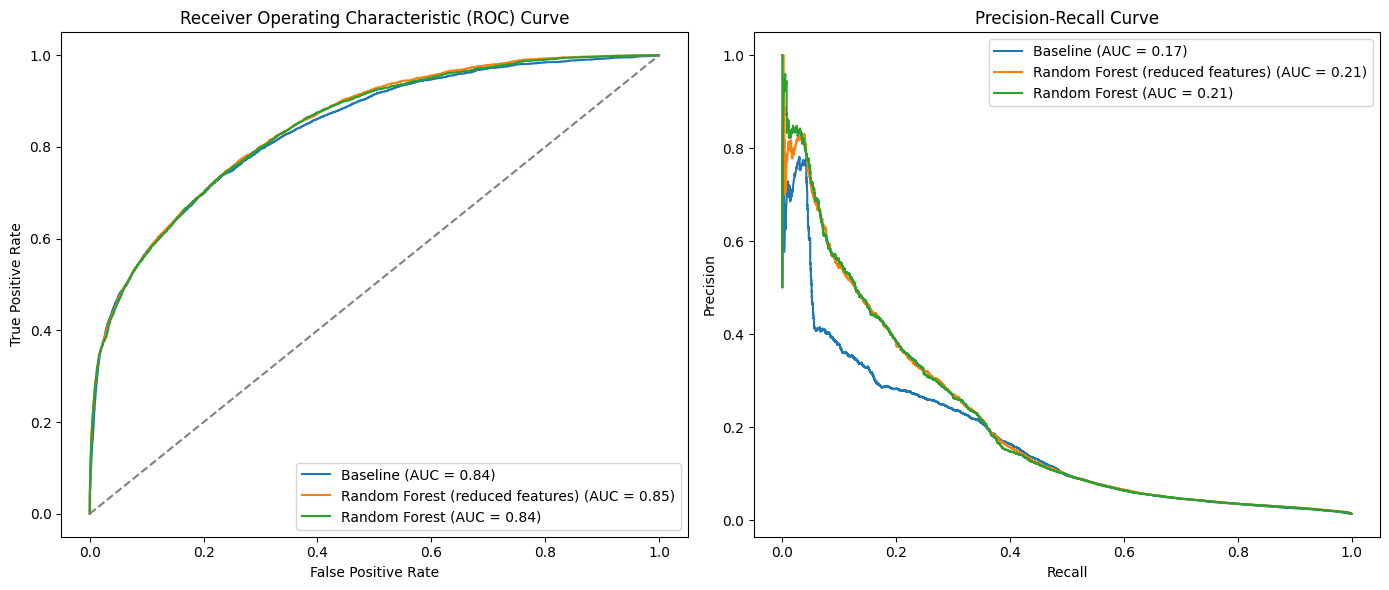

In [7]:
best_rf_reduced = RandomForestClassifier(**random_search.best_params_, random_state=42)
best_rf_reduced.fit(X_train[top_features], y_train)

plot_roc_pr_curves([baseline, best_rf_reduced, best_rf], [X_val, X_val[top_features], X_val], y_val, model_names=['Baseline', 'Random Forest (reduced features)', 'Random Forest'])

Here, as it was expected, the Random Forest with reduced features has pretty much the same predictive power as the Random Forest trained with every feature. We only see a few differences in their metrics: 
- The performance in the right side of the ROC curve is slightly better for the model with reduced variables (but this is almost irrelevant, as we are talking about a region with a False Positive Rate of around 0.6/0.8).
- The PR curve for the complete model seems to be better in the area around 0.8 precision. However, this region of the PR curve shows a lot of noise in every case. It would only be worth to make further analysis if these values of precision (0.8~0.85) are chosen.

### **XGBoost**

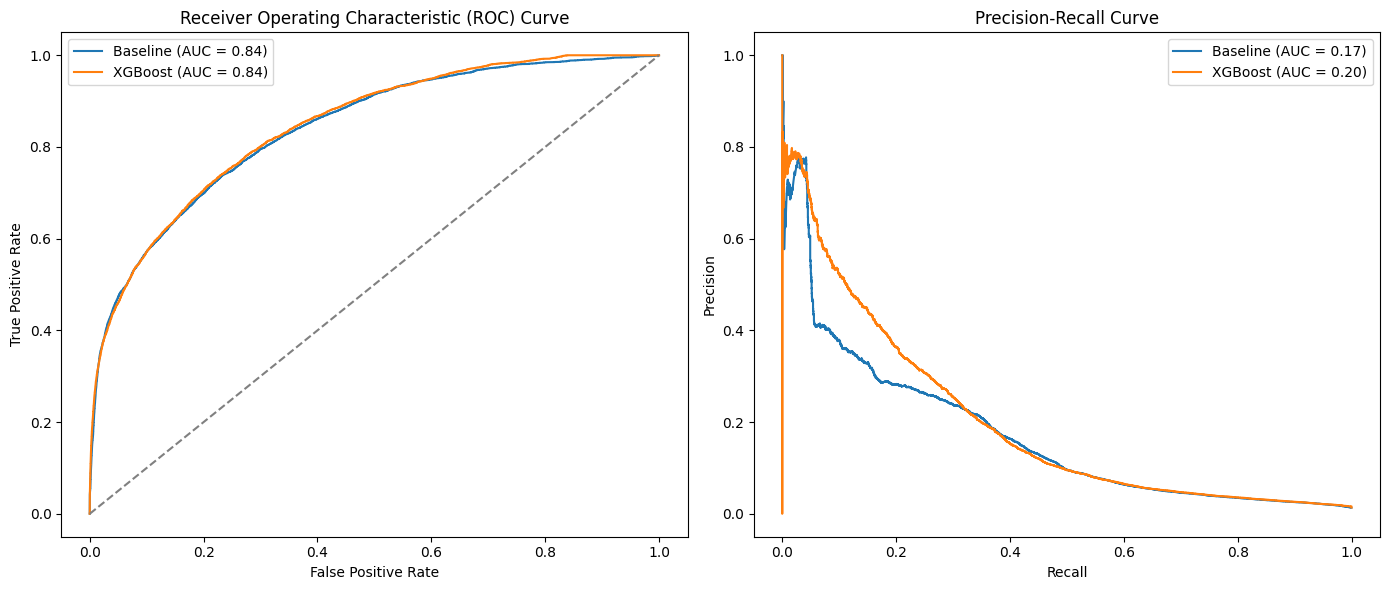

In [3]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

plot_roc_pr_curves([baseline, xgb_model], X_val, y_val, model_names=['Baseline', 'XGBoost'])

Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=150, subsample=0.8; total time=  10.5s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=150, subsample=0.8; total time=  10.6s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=7, min_child_weight=3, n_estimators=400, subsample=1.0; total time=  19.3s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=7, min_child_weight=3, n_estimators=400, subsample=1.0; total time=  19.8s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=3, n_estimators=300, subsample=1.0; total time=  12.2s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=3, n_estimators=300, subsample=1.0; total time=  12.3s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth

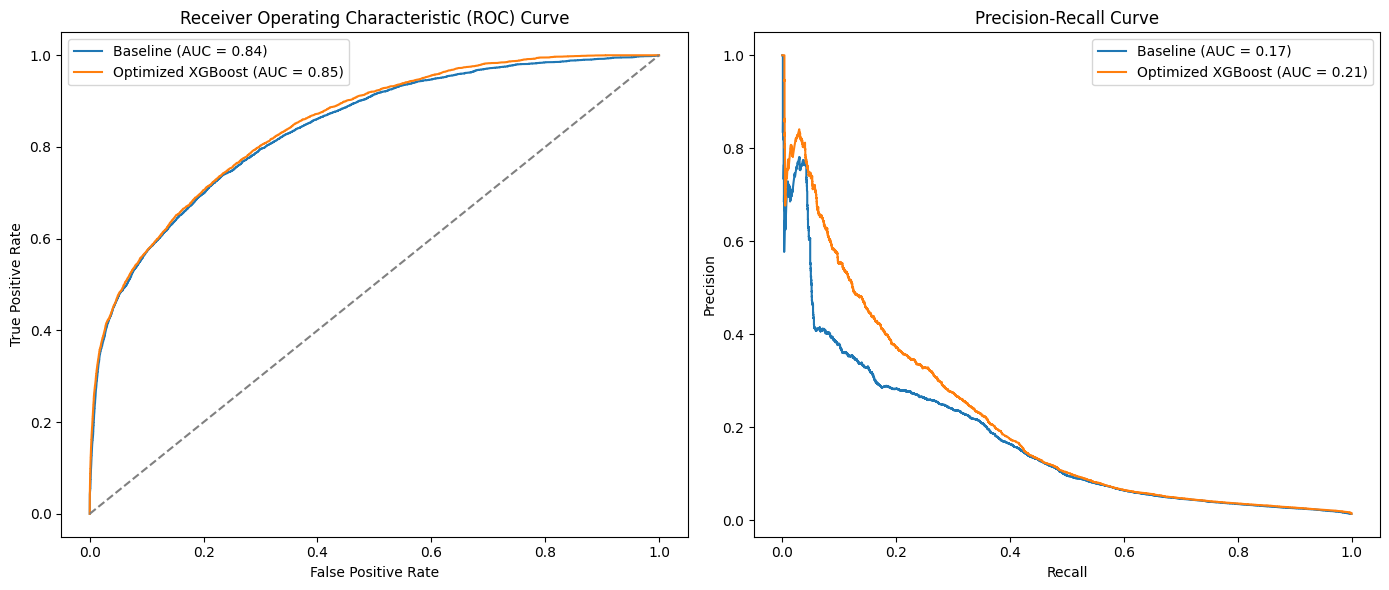

In [4]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': np.arange(50, 500, 50),  # Number of trees
    'max_depth': [3, 5, 7, 10],  # Tree depth
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Step size shrinkage
    'subsample': [0.6, 0.8, 1.0],  # Fraction of samples used for training
    'colsample_bytree': [0.6, 0.8, 1.0],  # Fraction of features used per tree
    'gamma': [0, 0.1, 0.2, 0.3],  # Minimum loss reduction required for a split
    'min_child_weight': [1, 3, 5]  # Minimum sum of weights in a child node
}

xgb = XGBClassifier(eval_metric='logloss', random_state=42)

random_search = RandomizedSearchCV(
    xgb, 
    param_distributions=param_grid, 
    n_iter=10,
    cv=2,
    scoring='roc_auc', 
    n_jobs=4, 
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_
print(f"Best Parameters: {random_search.best_params_}")

# plot_roc_pr_curves([baseline, best_xgb, best_rf], X_val, y_val, model_names=['Baseline', 'Optimized XGBoost', 'Optimized Random Forest'])
plot_roc_pr_curves([baseline, best_xgb], X_val, y_val, model_names=['Baseline', 'Optimized XGBoost'])

##### **Final comparative of both optimized models:**

In [ ]:
plot_roc_pr_curves([baseline, best_rf, best_xgb], X_val, y_val, model_names=['Baseline', 'Optimized Random Forest', 'Optimized XGBoost'])